In [10]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_ROOT = "/home/vatsdd/Desktop/bca_centralized/data/raw"
CENTERS   = ["Center_1", "Center_2", "Center_3", "Center_4"]

print("Libraries loaded ")

Libraries loaded 


In [11]:
def load_nii(path):
    img = nib.load(path)
    return img.get_fdata(), img.header

img_dir = Path(DATA_ROOT) / "Center_1" / "Image"
ann_dir = Path(DATA_ROOT) / "Center_1" / "Annotation"

file = list(img_dir.glob("*.nii.gz"))[0]

img_path  = str(file)
mask_path = str(ann_dir / file.name)

img, hdr  = load_nii(img_path)
mask, _   = load_nii(mask_path)

print(f"File used:          {file.name}")
print(f"Image shape:        {img.shape}")
print(f"Voxel spacing:      {[round(v,2) for v in hdr.get_zooms()]}")
print(f"Intensity range:    [{img.min():.1f}, {img.max():.1f}]")
print(f"Mask values:        {np.unique(mask)}")
print(f"Tumor voxels:       {int(mask.sum())}")

File used:          001.nii.gz
Image shape:        (320, 320, 23)
Voxel spacing:      [0.66, 0.66, 3.5]
Intensity range:    [0.0, 255.0]
Mask values:        [0. 1.]
Tumor voxels:       486


Tumor slices: [13 14 15]


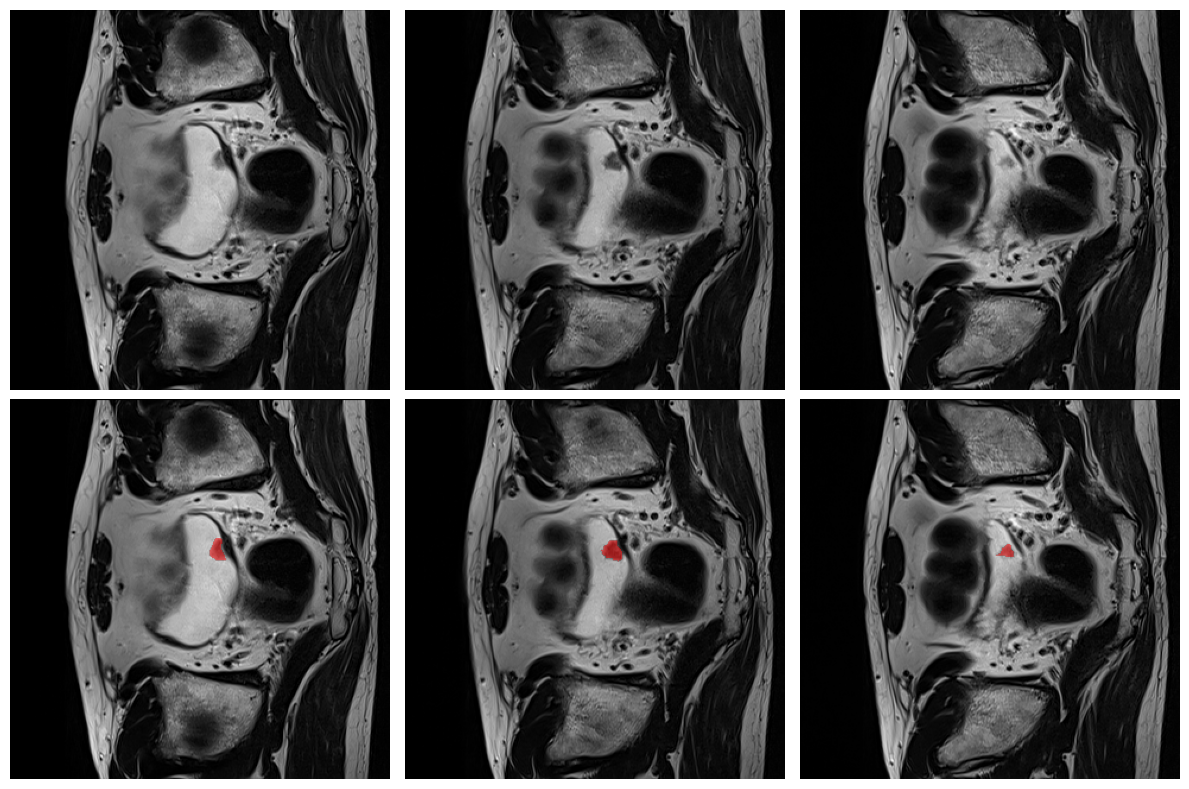

In [12]:
tumor_slices = np.where(mask.sum(axis=(0, 1)) > 0)[0]

print(f"Tumor slices: {tumor_slices}")

if len(tumor_slices) > 0:
    n = len(tumor_slices)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    if n == 1:
        axes = axes.reshape(2,1)

    for i, sl in enumerate(tumor_slices):
        axes[0,i].imshow(img[:,:,sl], cmap='gray')
        axes[0,i].axis('off')

        axes[1,i].imshow(img[:,:,sl], cmap='gray')
        overlay = np.zeros((*img[:,:,sl].shape, 4))
        overlay[mask[:,:,sl] > 0] = [1,0,0,0.5]
        axes[1,i].imshow(overlay)
        axes[1,i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No tumor found in this scan")

In [20]:
print("="*60)
print("DATASET STATISTICS")
print("="*60)

all_stats = []

for center in CENTERS:
    label_file = Path(DATA_ROOT) / center / f"{center}_label.xlsx"

    if not label_file.exists():
        print(f"{center}: label file missing")
        continue

    df = pd.read_excel(label_file)

    print(f"\n{center}")
    print(f"Total: {len(df)}")

    mibc_col = None
    for c in df.columns:
        if any(k in c.upper() for k in ["MIBC","LABEL","INVASION","MUSCLE"]):
            mibc_col = c
            break

    if mibc_col is None:
        mibc_col = df.columns[0]

    values = pd.to_numeric(df[mibc_col], errors='coerce').fillna(0)

    mibc  = int((values > 0).sum())
    nmibc = len(df) - mibc

    print(f"MIBC: {mibc}")
    print(f"NMIBC: {nmibc}")

    all_stats.append({"total":len(df),"mibc":mibc,"nmibc":nmibc})

total = sum(x["total"] for x in all_stats)

if total > 0:
    total_mibc = sum(x["mibc"] for x in all_stats)
    print("\nTOTAL:", total)
    print("MIBC %:", total_mibc/total*100)
else:
    print("No data found")

DATASET STATISTICS

Center_1
Total: 160
MIBC: 30
NMIBC: 130

Center_2
Total: 48
MIBC: 25
NMIBC: 23

Center_3
Total: 32
MIBC: 13
NMIBC: 19

Center_4
Total: 35
MIBC: 17
NMIBC: 18

TOTAL: 275
MIBC %: 30.909090909090907


In [19]:
import os
print(os.listdir("/home/vatsdd/Desktop/bca_centralized/data/raw/Center_4"))

['Annotation', 'Image', 'Center_4_label.xlsx~']


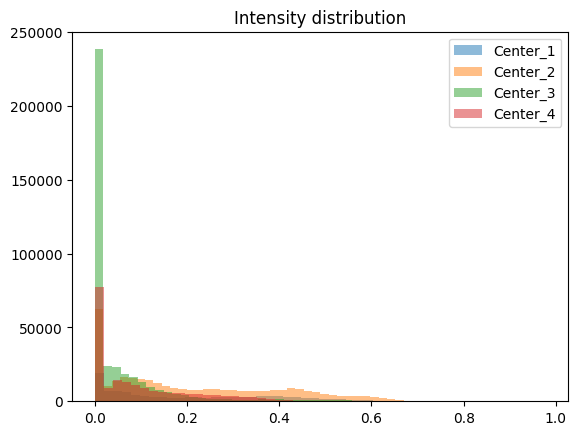

In [21]:
for center in CENTERS:
    img_dir = Path(DATA_ROOT) / center / "Image"

    if not img_dir.exists():
        continue

    intensities = []

    for f in list(img_dir.glob("*.nii.gz"))[:5]:
        data = nib.load(str(f)).get_fdata()
        data = (data - data.min())/(data.max()-data.min()+1e-8)
        intensities.extend(data.flatten()[::100])

    plt.hist(intensities, bins=50, alpha=0.5, label=center)

plt.legend()
plt.title("Intensity distribution")
plt.show()

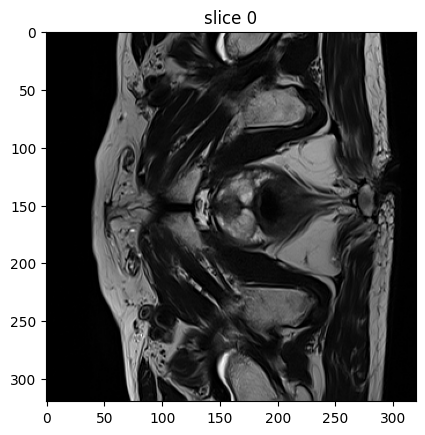

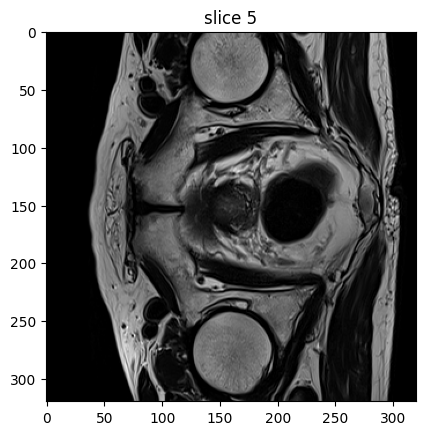

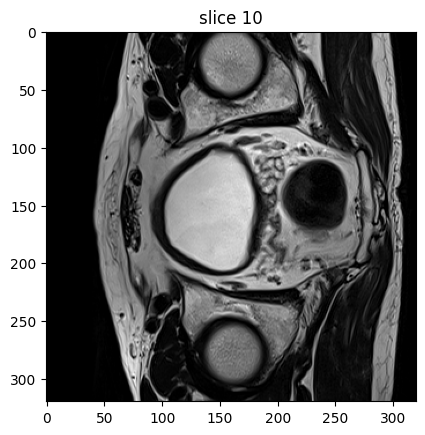

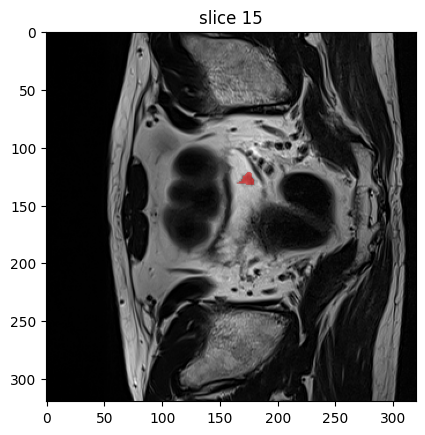

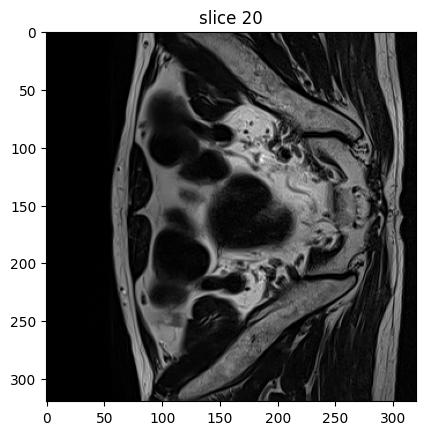

In [22]:

def show_slices(img_path, mask_path):
    img,_ = load_nii(img_path)
    mask,_ = load_nii(mask_path)

    for i in range(0, img.shape[2], 5):
        plt.imshow(img[:,:,i], cmap='gray')

        if mask[:,:,i].sum()>0:
            overlay = np.zeros((*img[:,:,i].shape,4))
            overlay[mask[:,:,i]>0] = [1,0,0,0.5]
            plt.imshow(overlay)

        plt.title(f"slice {i}")
        plt.show()

show_slices(img_path, mask_path)
